# 🌿 Green AI: Efficient Model Training with Re-Play it Straight
**6th Semester Final Project - Deep Learning Pipeline**

## 📖 Project Overview
This notebook implements **Play it Straight** and its enhanced variant **Re-Play it Straight**, a novel Green AI framework designed to drastically reduce the computational cost and carbon footprint of training Deep Neural Networks (DNNs).

Traditional model training—and even standard Active Learning (AL) or Data Pruning (DP) techniques—often introduces high energy overhead. This project solves that by synergistically combining:
* **RS2 Bootstrapping:** A lightweight, random subset sampling warmup phase to establish an informed model baseline.
* **Active Learning Fine-Tuning:** Iterative, high-value data selection using cheap-to-compute uncertainty and error scores (e.g., Least Confidence, Margin, Entropy).
* **Cyclical Learning Rates & Boost Epochs:** Adaptive optimization mechanisms to accelerate convergence, prevent overfitting, and escape local minima without excessive data processing.

## 🚀 Notebook Pipeline
This environment is configured to run the complete end-to-end evaluation:
1. **Repository Setup:** Clones the main project repository and establishes the Python path.
2. **Environment & Hardware:** Installs dependencies (including `codecarbon` for energy telemetry) and links to the Colab GPU.
3. **Data Orchestration:** Automatically fetches and formats benchmark datasets (CIFAR-10, CIFAR-100, Imagewoof, etc.).
4. **Energy-Efficient Training:** Executes the custom Active Learning loops on a ResNet18 model.
5. **Analytics & Visualization:** Extracts training logs to generate detailed dashboards mapping computational cost (backward steps) against predictive accuracy.

In [3]:
!git clone https://github.com/shazilhamzah/6thSemFP-GreenAI.git

Cloning into '6thSemFP-GreenAI'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (18/18), done.
^C


In [ ]:
!pip install codecarbon==3.2.6 prefetch_generator==1.0.3 ptflops==0.7.4 scikit_learn==1.4.2 kagglehub

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.0 MB/s eta 0:00:00
  Created wheel for prefetch_generator: filename=prefetch_generator-1.0.3-py3-none-any.whl size=4758 sha256=56b6ab88ed50f4efd096f8f6d36b9c8ad5fb76d30ce9276c51ebba7a271ee009
  Stored in directory: /root/.cache/pip/wheels/23/88/c7/3b5afc342fc80a599ce41ba9000cf8a71261991c35cf088edf
Successfully built prefetch_generator
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: scikit_learn
    Found existing installation: scikit-learn 1.6.1
    

In [ ]:
import os
# Change this to whatever your root folder is named in the Colab file explorer
os.chdir('/content/6thSemFP-GreenAI')

In [ ]:
!python download_all_datasets.py

Starting download of all datasets to: /content/6thSemFP-GreenAI/data

[+] Processing MNIST...
Attempting to download MNIST via Kaggle API...
Using Colab cache for faster access to the 'mnist-dataset' dataset.
Moving dataset from /kaggle/input/mnist-dataset to /content/6thSemFP-GreenAI/data/mnist...
Dataset ready at /content/6thSemFP-GreenAI/data/mnist
[OK] MNIST download complete.

[+] Processing SVHN...
Attempting to download SVHN via Kaggle API...
Using Colab cache for faster access to the 'street-view-house-numbers' dataset.
Moving dataset from /kaggle/input/street-view-house-numbers to /content/6thSemFP-GreenAI/data/svhn...
Traceback (most recent call last):
  File "/content/6thSemFP-GreenAI/download_all_datasets.py", line 78, in <module>
    download_all()
  File "/content/6thSemFP-GreenAI/download_all_datasets.py", line 35, in download_all
    download_from_kaggle(info["handle"], target_dir)
  File "/content/6thSemFP-GreenAI/RePlayItStraight/src/re_play_it_straight/support/kaggle

In [ ]:
!python run_all_colab.py

Starting sequential dataset evaluation...

 Running Experiment for: ImageNet30 (Classes: 30) 
 Logging to: ./RePlayItStraight/results/ImageNet30_Log.txt
args:  Namespace(n_split=3, boot_epochs=20, target_accuracy=90, discount_rs2=2.0, boost_threshold=0.07, dataset='ImageNet30', n_class=30, cycle=10, n_query=1000, subset=1000000, resolution=32, model='ResNet18', epochs=10, data_path='./data', gpu=[0], print_freq=300, seed=42, workers=0, optimizer='SGD', lr=0.1, min_lr=0.0001, momentum=0.9, weight_decay=0.0005, nesterov=True, scheduler='CosineAnnealingLR', gamma=0.5, step_size=50, batch_size=128, test_batch_size=500, test_interval=1, test_fraction=1.0, balance=False, method='ImprovedUncertainty', submodular='GraphCut', submodular_greedy='LazyGreedy', uncertainty='LeastConfidence', save_path='./RePlayItStraight/results', resume='', device='cuda:0')
Resizing Initial Data into 32x32
Traceback (most recent call last):
  File "/content/6thSemFP-GreenAI/./RePlayItStraight/src/re_play_it_straig

Success! High-res PNG and Vector SVG saved to /content/6thSemFP-GreenAI/RePlayItStraight/results/Processed/Energy_Dashboard


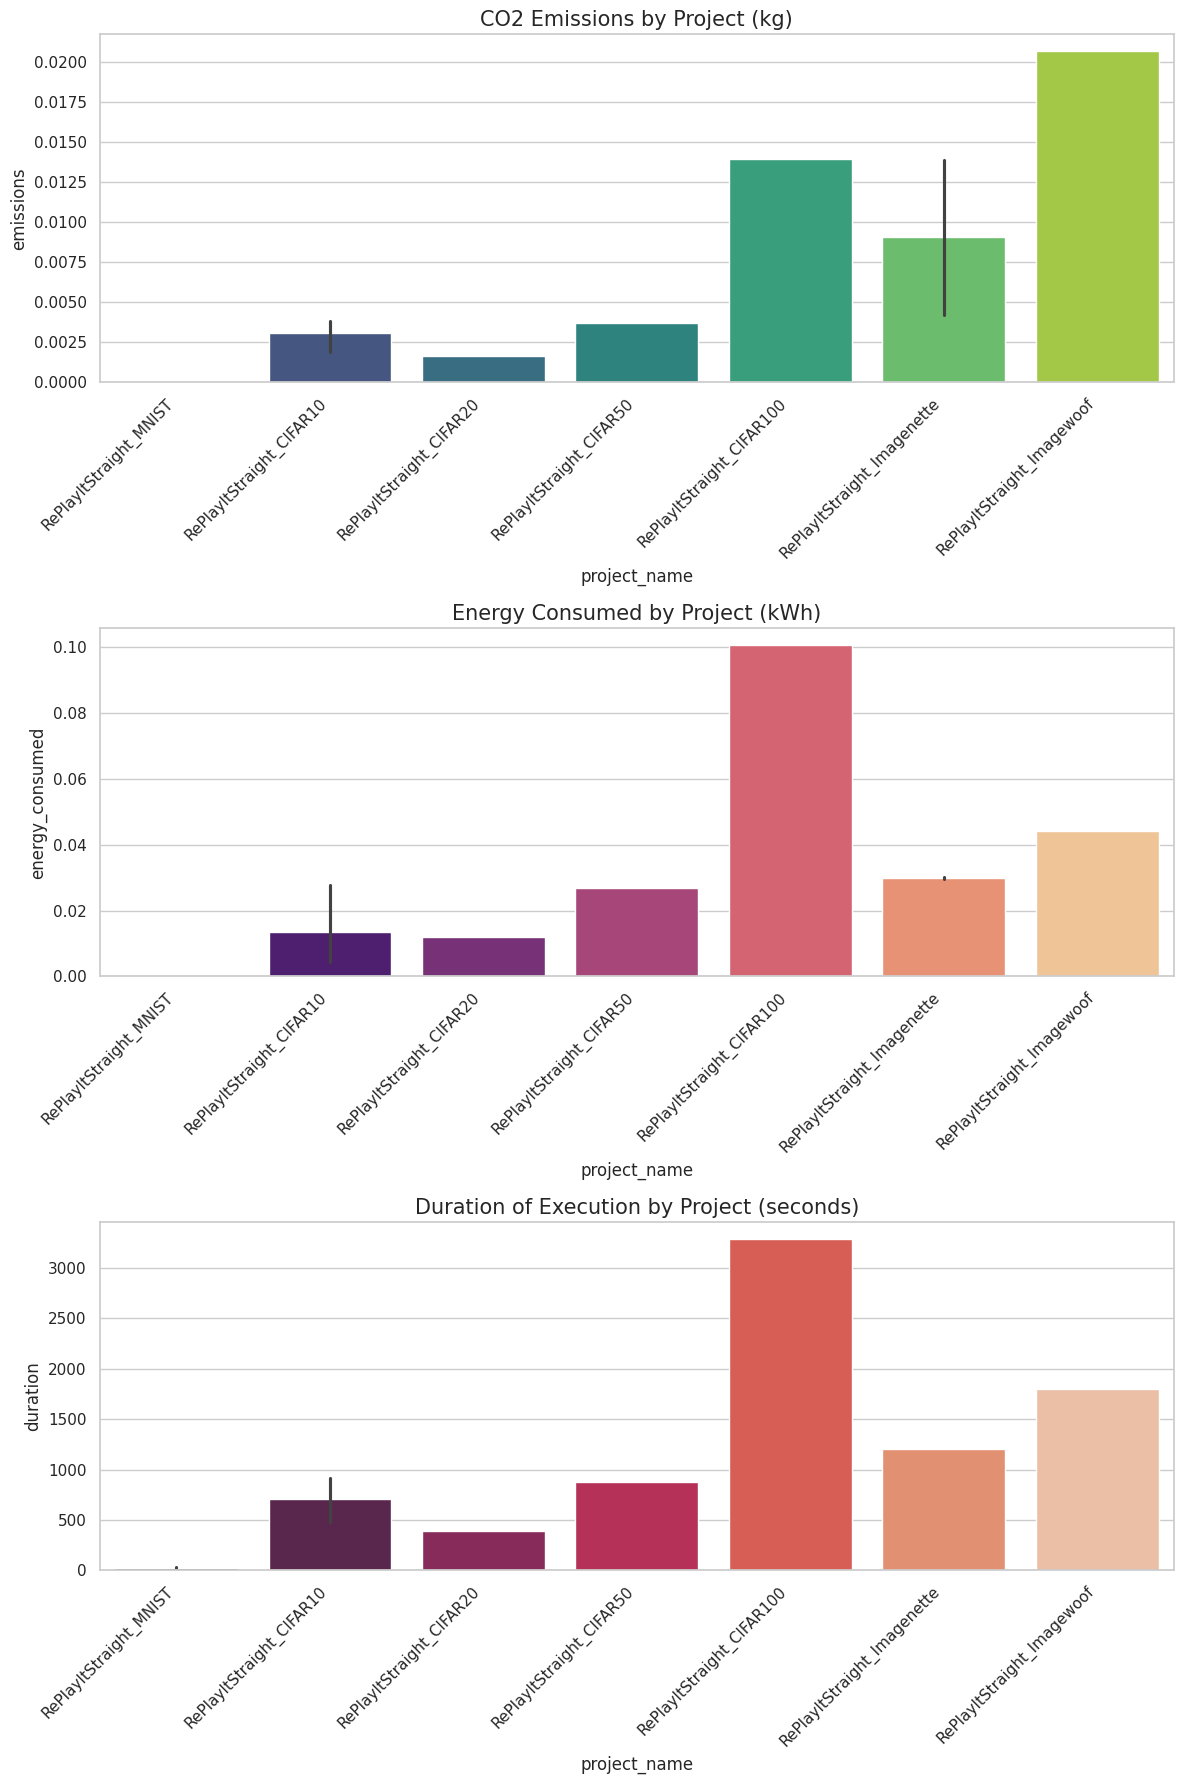

In [ ]:
import pandas as pd
import os

df = pd.read_csv("/content/6thSemFP-GreenAI/emissions.csv")

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Emissions per Project
sns.barplot(ax=axes[0], x='project_name', y='emissions', data=df, hue='project_name', palette='viridis', legend=False)
axes[0].set_title('CO2 Emissions by Project (kg)', fontsize=15)
axes[0].set_xticks(range(len(df['project_name'].unique())))
axes[0].set_xticklabels(df['project_name'].unique(), rotation=45, ha='right')

# 2. Energy Consumed per Project
sns.barplot(ax=axes[1], x='project_name', y='energy_consumed', data=df, hue='project_name', palette='magma', legend=False)
axes[1].set_title('Energy Consumed by Project (kWh)', fontsize=15)
axes[1].set_xticks(range(len(df['project_name'].unique())))
axes[1].set_xticklabels(df['project_name'].unique(), rotation=45, ha='right')

# 3. Duration per Project
sns.barplot(ax=axes[2], x='project_name', y='duration', data=df, hue='project_name', palette='rocket', legend=False)
axes[2].set_title('Duration of Execution by Project (seconds)', fontsize=15)
axes[2].set_xticks(range(len(df['project_name'].unique())))
axes[2].set_xticklabels(df['project_name'].unique(), rotation=45, ha='right')

save_base = os.path.join("/content/6thSemFP-GreenAI/RePlayItStraight/results/Processed/Energy_Dashboard")
plt.savefig(f"{save_base}.png", dpi=300)
plt.savefig(f"{save_base}.svg", format='svg')
print(f"Success! High-res PNG and Vector SVG saved to {"/content/6thSemFP-GreenAI/RePlayItStraight/results/Processed/Energy_Dashboard"}")

plt.tight_layout()
plt.show()

In [ ]:
import re
import sys
import os

def process_log(filepath):
    if not os.path.exists(filepath):
        print(f"Error: File '{filepath}' not found.")
        return

    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    # Strip ANSI terminal color codes from the raw log
    ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')
    clean_content = ansi_escape.sub('', content)

    # Regex patterns for extracting key metrics
    cycle_pattern = re.compile(r'Cycle (\d+) \|\| Label set size (\d+) \| Accuracy: ([\d.]+), Precision: ([\d.]+), Recall: ([\d.]+), F1: ([\d.]+)')
    step_pattern = re.compile(r'Done (\d+) backward steps')
    emissions_pattern = re.compile(r'Total Experiment Emissions: ([\d.]+) kg CO2eq')

    cycles_data = []
    current_cycle = {}

    for line in clean_content.split('\n'):
        cycle_match = cycle_pattern.search(line)
        if cycle_match:
            current_cycle = {
                'Cycle': cycle_match.group(1),
                'Label Set Size': cycle_match.group(2),
                'Accuracy': cycle_match.group(3),
                'Precision': cycle_match.group(4),
                'Recall': cycle_match.group(5),
                'F1': cycle_match.group(6)
            }

        step_match = step_pattern.search(line)
        if step_match and current_cycle:
            current_cycle['Backward Steps'] = step_match.group(1)
            cycles_data.append(current_cycle)
            current_cycle = {}

    emissions_match = emissions_pattern.search(clean_content)
    emissions = emissions_match.group(1) if emissions_match else "N/A"

    # Construct output filename
    base_name, _ = os.path.splitext(filepath)
    out_filepath = f"{base_name}_processed.csv"

    # Write extracted data to CSV
    with open(out_filepath, 'w', encoding='utf-8') as f:
        f.write("Cycle,Label Set Size,Backward Steps,Accuracy,Precision,Recall,F1\n")
        for c in cycles_data:
            f.write(f"{c.get('Cycle','')},{c.get('Label Set Size','')},{c.get('Backward Steps','')},"
                    f"{c.get('Accuracy','')},{c.get('Precision','')},{c.get('Recall','')},{c.get('F1','')}\n")



    print(f"Extraction complete. Data saved to: {out_filepath}")

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def generate_combined_processed_graphs(results_dir="."):
    # 1. Find all processed CSV files in the target directory
    # Adjust this path if your files are in a specific folder (e.g., "./results")
    search_pattern = os.path.join(results_dir, "*_processed.csv")
    csv_files = glob.glob(search_pattern)

    if not csv_files:
        print(f"Error: No files ending in '_processed.csv' found in {results_dir}")
        return

    print(f"Found {len(csv_files)} datasets. Generating combined dashboard...")

    # 2. Set up the shared Dashboard
    fig = plt.figure(figsize=(18, 6))
    fig.suptitle("Re-Play it Straight: Cross-Dataset Comparison", fontsize=18, fontweight='bold')

    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3)

    # 3. Loop through every file and add it to the plots
    for filepath in csv_files:
        # Extract dataset name (e.g., "CIFAR10" from "CIFAR10_Log_processed.csv")
        dataset_name = os.path.basename(filepath).split('_')[0]

        # Load and clean the data (remove the 'Total Emissions' text row)
        df = pd.read_csv(filepath)
        df = df[pd.to_numeric(df['Cycle'], errors='coerce').notnull()].copy()

        # Convert necessary columns to floats
        numeric_cols = ['Cycle', 'Label Set Size', 'Backward Steps', 'Accuracy']
        df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

        # Plot A: Compute vs Accuracy
        ax1.plot(df['Backward Steps'], df['Accuracy'], marker='o', linestyle='-', linewidth=2, label=dataset_name)

        # Plot B: Data Usage Scaling
        ax2.plot(df['Cycle'], df['Label Set Size'], marker='s', linestyle='-', linewidth=2, label=dataset_name)

        # Plot C: Computational Scaling
        ax3.plot(df['Cycle'], df['Backward Steps'], marker='^', linestyle='-', linewidth=2, label=dataset_name)

    # 4. Format the Graphs and add Legends
    # Graph A
    ax1.set_title("Computational Cost vs Test Accuracy")
    ax1.set_xlabel("Cumulative Backward Steps")
    ax1.set_ylabel("Accuracy (%)")
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='lower right')

    # Graph B
    ax2.set_title("Data Usage Scaling")
    ax2.set_xlabel("AL Round (Cycle)")
    ax2.set_ylabel("Labeled Samples Used")
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper left')

    # Graph C
    ax3.set_title("Computational Scaling")
    ax3.set_xlabel("AL Round (Cycle)")
    ax3.set_ylabel("Cumulative Backward Steps")
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='upper left')

    # 5. Final Polish and Save
    plt.tight_layout(rect=[0, 0.03, 1, 0.90]) # Leave room for the main title

    # Saving in multiple high-quality formats
    save_base = os.path.join(results_dir, "Combined_CrossDataset_Dashboard")
    plt.savefig(f"{save_base}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_base}.svg", format='svg', bbox_inches='tight')
    print(f"Success! High-res PNG and Vector SVG saved to {results_dir}")

    plt.show()

Error: No files ending in '_processed.csv' found in .


In [ ]:
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR100_Log.txt")
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR10_Log.txt")
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR20_Log.txt")
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR50_Log.txt")
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/Imagenette_Log.txt")
process_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/Imagewoof_Log.txt")


Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR100_Log_processed.csv
Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR10_Log_processed.csv
Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR20_Log_processed.csv
Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR50_Log_processed.csv
Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/Imagenette_Log_processed.csv
Extraction complete. Data saved to: /content/6thSemFP-GreenAI/RePlayItStraight/results/Imagewoof_Log_processed.csv


Graphs successfully generated and saved as: CIFAR100_processed_dashboard.png


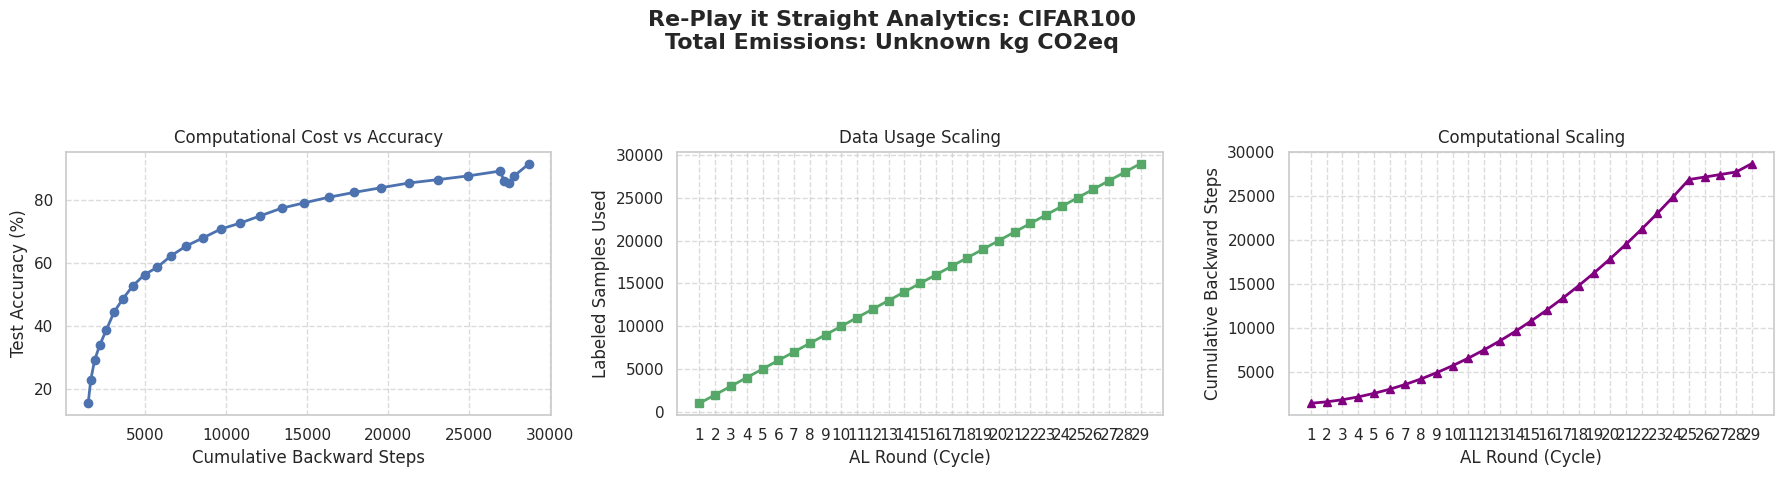

Graphs successfully generated and saved as: CIFAR10_processed_dashboard.png


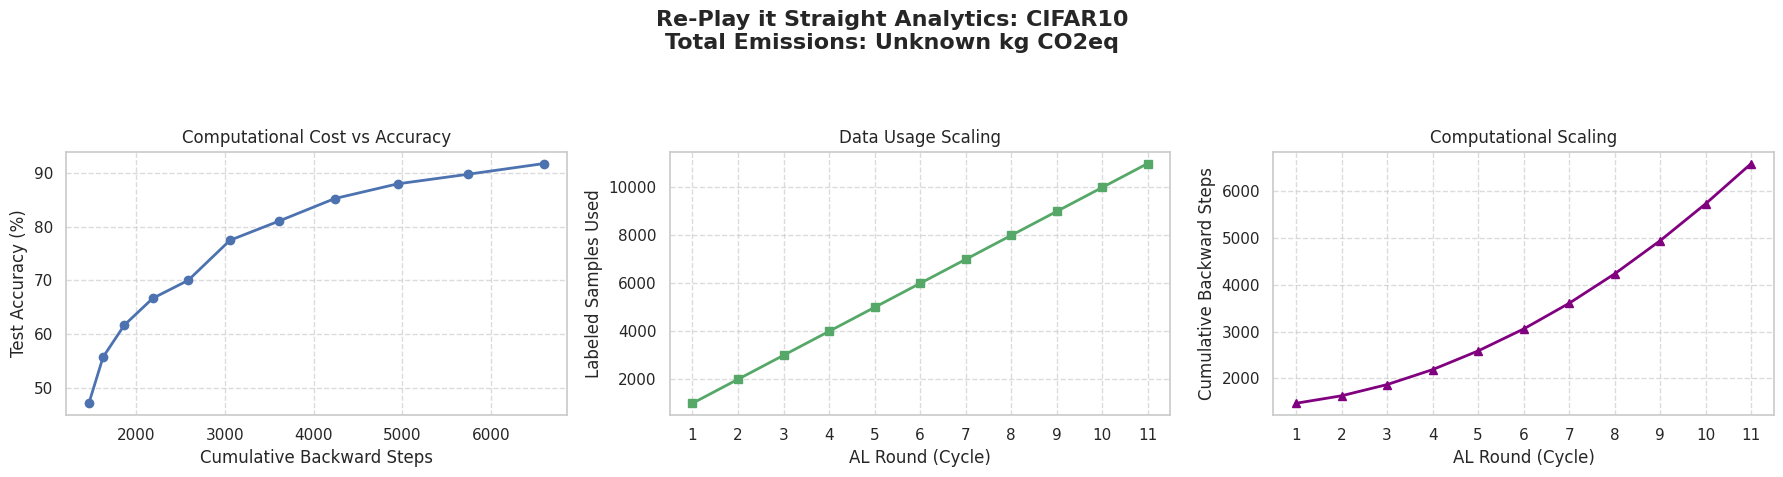

Graphs successfully generated and saved as: CIFAR20_processed_dashboard.png


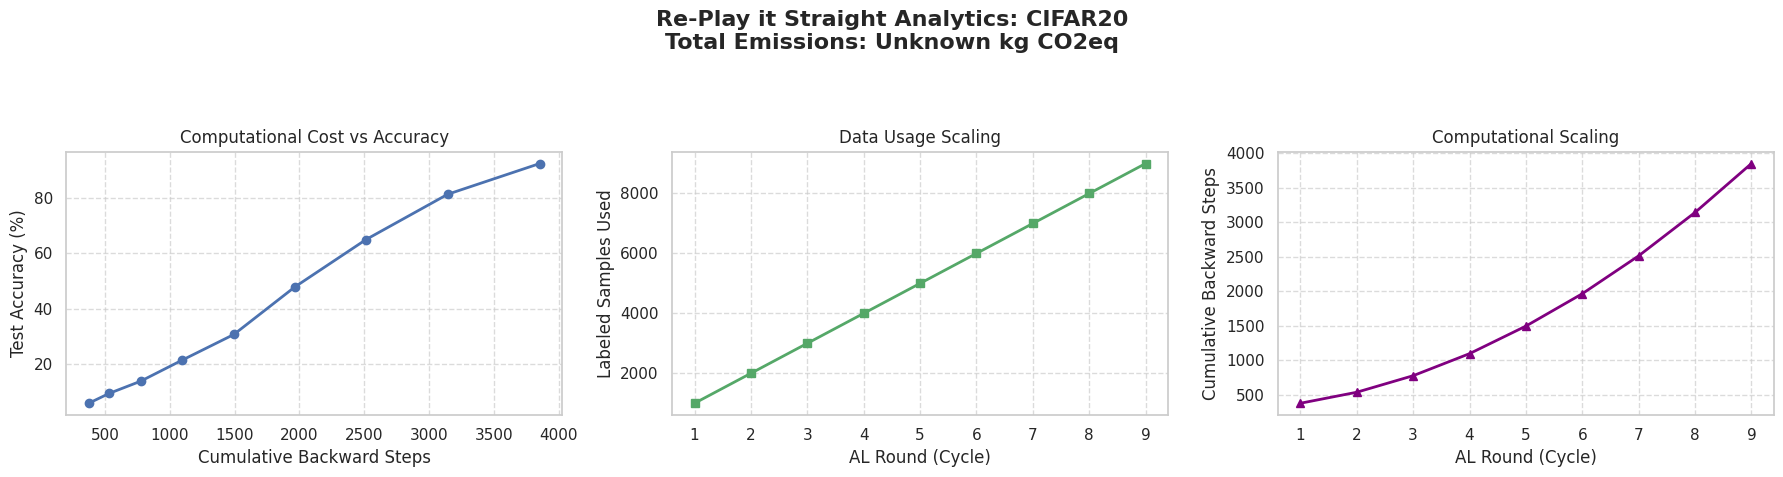

Graphs successfully generated and saved as: CIFAR50_processed_dashboard.png


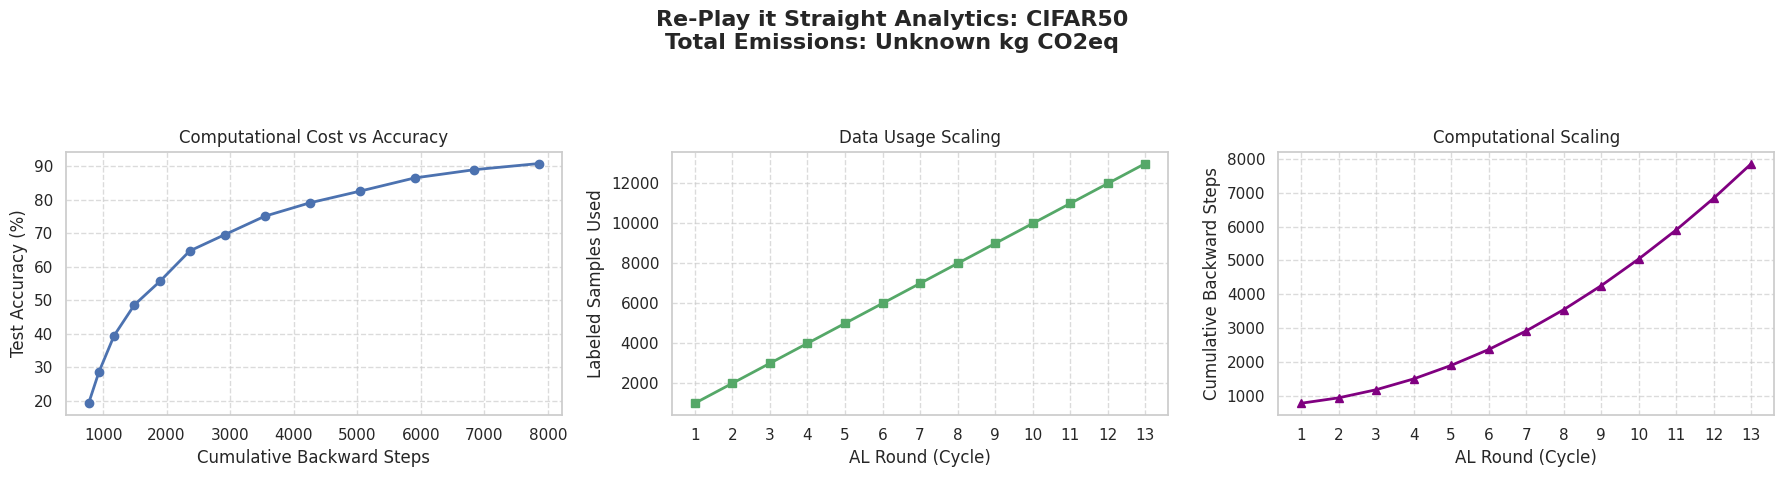

Graphs successfully generated and saved as: Imagenette_processed_dashboard.png


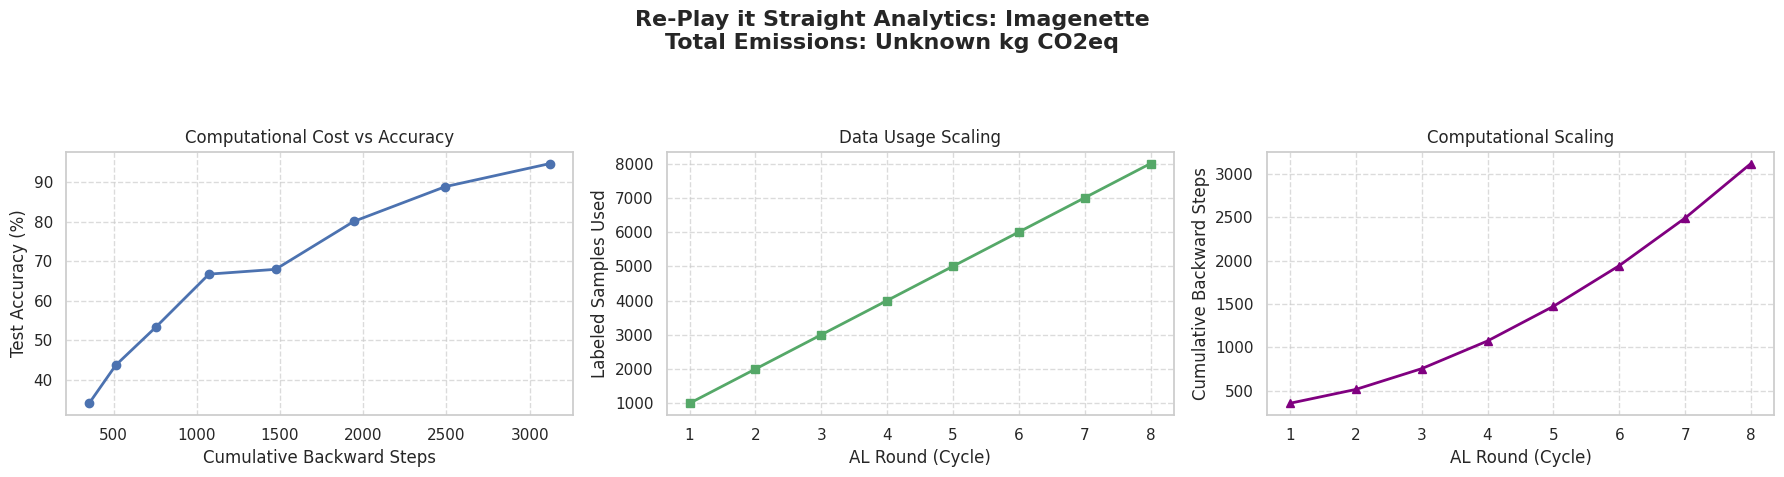

Graphs successfully generated and saved as: Imagewoof_processed_dashboard.png


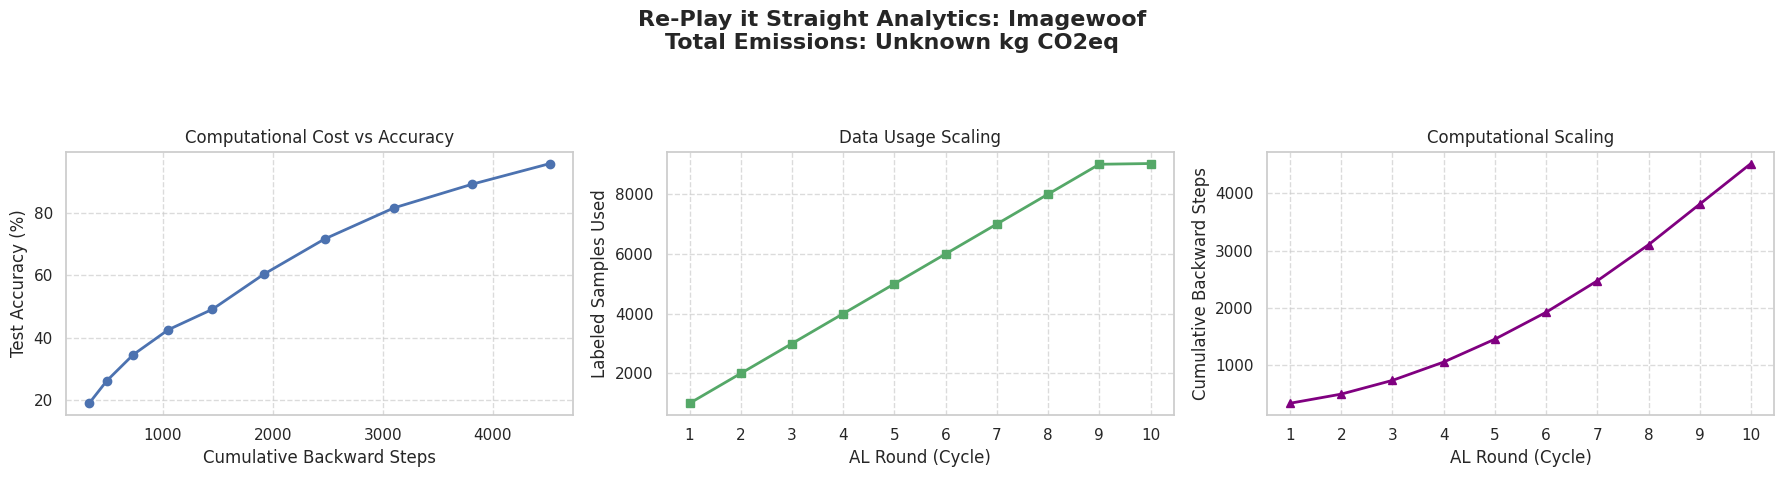

In [ ]:
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR100_Log_processed.csv")
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR10_Log_processed.csv")
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR20_Log_processed.csv")
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/CIFAR50_Log_processed.csv")
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/Imagenette_Log_processed.csv")
generate_graphs_from_processed_log("/content/6thSemFP-GreenAI/RePlayItStraight/results/Imagewoof_Log_processed.csv")


Found 6 datasets. Generating combined dashboard...
Success! High-res PNG and Vector SVG saved to /content/6thSemFP-GreenAI/RePlayItStraight/results/


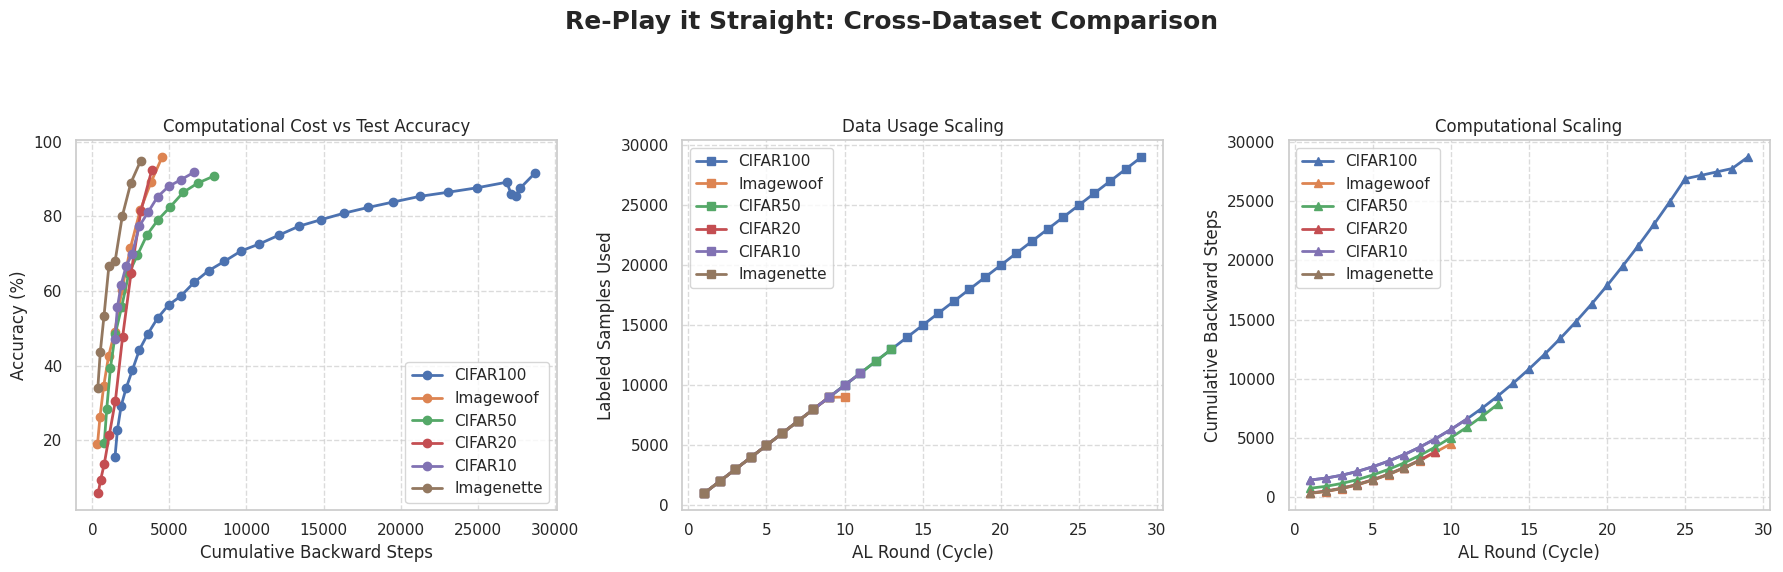

In [ ]:
generate_combined_processed_graphs("/content/6thSemFP-GreenAI/RePlayItStraight/results/")

In [ ]:
!zip -r 6thSemFP-GreenAI_BackUp.zip 6thSemFP-GreenAI